In [ ]:
!pip install progress-table

In [ ]:
!pip install piq

In [15]:
# 📦 Core Libraries
import os
import random
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
from PIL import Image
import matplotlib.pyplot as plt
from progress_table import ProgressTable
import cv2

# 🔧 PyTorch and Metrics
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import vgg19
from torchvision.models.feature_extraction import create_feature_extractor
from torchvision.utils import save_image
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [18]:
from piq import psnr, ssim

In [ ]:
# ⚙️ Global Configuration
class CFG:
    # Data Paths
    ROOT_DIR = "/kaggle/input/manga109s/Manga109s"
    TRAIN_CSV = os.path.join(ROOT_DIR, "train.csv")
    VAL_CSV = os.path.join(ROOT_DIR, "val.csv")
    TEST_CSV = os.path.join(ROOT_DIR, "test.csv")
    
    # Training Hyperparameters
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    EPOCHS = 60 # A higher resolution and GAN needs more time to converge
    
    BATCH_SIZE = 1 
    GRAD_ACCUM_STEPS = 4 # Effective batch size of 4

    # <<< --- THE UPGRADE --- >>>
    IMAGE_SIZE = 256 # Target resolution
    
    NUM_WORKERS = 2
    LR = 2e-4
    SEED = 43
    EPOCH_SWITCH = 15

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(CFG.SEED)
print(f"✅ Setup complete for {CFG.IMAGE_SIZE}x{CFG.IMAGE_SIZE} training. Using device: {CFG.DEVICE}")

✅ Setup complete for 256x256 training. Using device: cuda


In [20]:
def parse_text_bboxes(annotation_path, page_index, image_size, original_size):
    """Extracts and scales text bounding boxes from Manga109 XML annotation."""
    try:
        tree = ET.parse(annotation_path)
        root = tree.getroot()
        pages = root.findall('page')
        if page_index >= len(pages):
            return []
            
        original_w, original_h = original_size
        scale_x = image_size / original_w
        scale_y = image_size / original_h
        
        boxes = []
        for text in pages[page_index].findall('text'):
            x = int(text.get("x"))
            y = int(text.get("y"))
            w = int(text.get("width"))
            h = int(text.get("height"))
            # Scale the box coordinates
            boxes.append((int(x * scale_x), int(y * scale_y), int((x + w) * scale_x), int((y + h) * scale_y)))
        return boxes
    except (FileNotFoundError, ET.ParseError):
        return []

def generate_irregular_mask_excluding_boxes(shape, exclusion_boxes, **kwargs):
    """Generate random irregular mask, ensuring exclusion zones are not masked."""
    height, width = shape
    mask = np.zeros((height, width), dtype=np.uint8)
    for _ in range(random.randint(1, 5)):
        num_vertex = random.randint(5, 12)
        start_x = random.randint(0, width)
        start_y = random.randint(0, height)
        brush_width = random.randint(10, 20)
        angle = random.uniform(0, 2 * np.pi)
        for _ in range(num_vertex):
            angle += random.uniform(-np.pi/3, np.pi/3)
            length = random.randint(20, 70)
            end_x = np.clip(int(start_x + length * np.cos(angle)), 0, width - 1)
            end_y = np.clip(int(start_y + length * np.sin(angle)), 0, height - 1)
            cv2.line(mask, (start_x, start_y), (end_x, end_y), 1, brush_width)
            start_x, start_y = end_x, end_y
            
    for (x1, y1, x2, y2) in exclusion_boxes:
        mask[y1:y2, x1:x2] = 0 # Set exclusion zones to 0
    return torch.from_numpy(mask).float().unsqueeze(0)

class Manga109InpaintingDataset(Dataset):
    def __init__(self, csv_path, root_dir, image_size):
        self.data = pd.read_csv(csv_path)
        self.root_dir = root_dir
        self.image_size = image_size
        
        # CRITICAL FIX 1: Add Normalize for [-1, 1] range.
        self.transform = T.Compose([
            T.Resize((image_size, image_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.5], std=[0.5])
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_path = os.path.join(self.root_dir, row['image_path'])
        annotation_path = os.path.join(self.root_dir, row.get('annotation_path', ''))
        page_index = int(row.get('page_index', 0))

        image = Image.open(image_path).convert('L')
        original_size = image.size
        image_tensor = self.transform(image)
        
        exclusion_boxes = parse_text_bboxes(annotation_path, page_index, self.image_size, original_size)
        mask_tensor = generate_irregular_mask_excluding_boxes((self.image_size, self.image_size), exclusion_boxes)

        # CRITICAL FIX 2: Use zero-fill masking instead of white-fill.
        masked_image = image_tensor * (1.0 - mask_tensor)

        return {
            'image': image_tensor,
            'masked_image': masked_image,
            'mask': mask_tensor,
        }




In [21]:
# This is the final, memory-safe architecture for 256x256 training.
# It uses Gradient Checkpointing to trade speed for a massive reduction in memory usage.

from torch.utils.checkpoint import checkpoint

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class Attention(nn.Module):
    def __init__(self, dim, num_heads=8):
        super().__init__()
        self.num_heads = num_heads
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        x = F.scaled_dot_product_attention(q, k, v)
        x = x.transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        return x

class GatedFFN(nn.Module):
    def __init__(self, dim, mlp_ratio=4.):
        super().__init__()
        hidden_features = int(dim * mlp_ratio)
        self.fc1 = nn.Linear(dim, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, dim)
    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn = GatedFFN(dim)
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x

class TFormerUNet(nn.Module):
    # Pruned to be "thinner" as a safety margin.
    def __init__(self, in_ch=1, base_dim=24):
        super().__init__()
        
        # --- Encoder (Deeper for 256x256) ---
        self.enc1 = ConvBlock(in_ch, base_dim)               # -> 24, 256, 256
        self.down1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(base_dim, base_dim * 2)        # -> 48, 128, 128
        self.down2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(base_dim * 2, base_dim * 4)    # -> 96, 64, 64
        self.down3 = nn.MaxPool2d(2)
        
        # --- Bottleneck (Transformer) ---
        self.proj_in = nn.Conv2d(base_dim * 4, base_dim * 8, 1) # -> 192, 32, 32
        self.transformer = TransformerBlock(base_dim * 8, num_heads=8)
        self.proj_out = nn.Conv2d(base_dim * 8, base_dim * 4, 1) # -> 96, 32, 32

        # --- Decoder (Deeper) ---
        self.up3 = nn.ConvTranspose2d(base_dim * 4, base_dim * 2, 2, stride=2)
        self.dec3 = ConvBlock(base_dim * 6, base_dim * 2) # Skip from enc3 (96) + up3 (48) = 144
        self.up2 = nn.ConvTranspose2d(base_dim * 2, base_dim, 2, stride=2)
        self.dec2 = ConvBlock(base_dim * 3, base_dim)      # Skip from enc2 (48) + up2 (24) = 72
        self.up1 = nn.ConvTranspose2d(base_dim, base_dim, 2, stride=2)
        self.dec1 = ConvBlock(base_dim * 2, base_dim)      # Skip from enc1 (24) + up1 (24) = 48
        
        self.final_conv = nn.Conv2d(base_dim, in_ch, 1)

    def forward(self, x):
        # --- Encoder with Gradient Checkpointing ---
        # We apply checkpointing to the most memory-intensive blocks.
        skip1 = checkpoint(self.enc1, x, use_reentrant=False)
        down1 = self.down1(skip1)
        skip2 = checkpoint(self.enc2, down1, use_reentrant=False)
        down2 = self.down2(skip2)
        skip3 = checkpoint(self.enc3, down2, use_reentrant=False)
        down3 = self.down3(skip3)
        
        # --- Bottleneck ---
        B, C, H, W = down3.shape
        bn = self.proj_in(down3)
        bn_seq = bn.flatten(2).transpose(1, 2)
        # Checkpoint the transformer as well
        bn_seq = checkpoint(self.transformer, bn_seq, use_reentrant=False)
        bn_img = bn_seq.transpose(1, 2).view(B, -1, H, W)
        bn = self.proj_out(bn_img)

        # --- Decoder ---
        up3 = self.up3(bn)
        dec3 = self.dec3(torch.cat([up3, skip3], 1))
        up2 = self.up2(dec3)
        dec2 = self.dec2(torch.cat([up2, skip2], 1))
        up1 = self.up1(dec2)
        dec1 = self.dec1(torch.cat([up1, skip1], 1))
        
        return torch.tanh(self.final_conv(dec1))

In [22]:
# --- Cell 5b: Discriminator with Feature Extraction Capability ---
class Discriminator(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.block1 = self._discriminator_block(in_channels, 64, norm=False)
        self.block2 = self._discriminator_block(64, 128)
        self.block3 = self._discriminator_block(128, 256)
        self.block4 = self._discriminator_block(256, 512, stride=1)
        self.final_conv = nn.Conv2d(512, 1, 4, padding=1)
    def _discriminator_block(self, in_filters, out_filters, stride=2, norm=True):
        layers = [nn.Conv2d(in_filters, out_filters, 4, stride=stride, padding=1)]
        if norm: layers.append(nn.InstanceNorm2d(out_filters))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        return nn.Sequential(*layers)
    def forward(self, img, return_features=False):
        feat1 = self.block1(img)
        feat2 = self.block2(feat1)
        feat3 = self.block3(feat2)
        feat4 = self.block4(feat3)
        prediction = self.final_conv(feat4)
        if return_features:
            return prediction, [feat1, feat2, feat3, feat4]
        return prediction

In [23]:
class EdgeAwareLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, pred, target, mask):
        sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32, device=pred.device).view(1, 1, 3, 3)
        sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32, device=pred.device).view(1, 1, 3, 3)
        
        # FIX: Add a small epsilon inside the sqrt to prevent inf gradients at zero.
        epsilon = 1e-6
        pred_edges = torch.sqrt(F.conv2d(pred, sobel_x, padding=1)**2 + F.conv2d(pred, sobel_y, padding=1)**2 + epsilon)
        target_edges = torch.sqrt(F.conv2d(target, sobel_x, padding=1)**2 + F.conv2d(target, sobel_y, padding=1)**2 + epsilon)
        
        diff = torch.abs(pred_edges - target_edges) * mask
        return diff.sum() / (mask.sum() + epsilon)

class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        # FIX: Specify weights explicitly to avoid warnings
        vgg = vgg19(weights='IMAGENET1K_V1').features.eval()
        self.vgg = create_feature_extractor(vgg, return_nodes={'3':'r1','8':'r2','17':'r3'})
        for param in self.parameters():
            param.requires_grad = False
    def forward(self, pred, target):
        pred_feats = self.vgg(pred.repeat(1, 3, 1, 1))
        target_feats = self.vgg(target.repeat(1, 3, 1, 1))
        return sum(F.l1_loss(pred_feats[k], target_feats[k]) for k in pred_feats)

In [24]:
# --- Instantiate DataLoaders ---
train_dataset = Manga109InpaintingDataset(CFG.TRAIN_CSV, CFG.ROOT_DIR, CFG.IMAGE_SIZE)
val_dataset = Manga109InpaintingDataset(CFG.VAL_CSV, CFG.ROOT_DIR, CFG.IMAGE_SIZE)
train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=CFG.NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=CFG.NUM_WORKERS)

# <<< --- THE FIX FOR STAGNATION: DIFFERENTIAL LEARNING RATES (TTUR) --- >>>
# The Discriminator learns faster, becoming a tougher critic and forcing the
# Generator to produce sharper, more realistic images.
LR_G = CFG.LR      # e.g., 2e-4
LR_D = CFG.LR * 4  # e.g., 8e-4
print(f"Generator LR: {LR_G:.2e} | Discriminator LR: {LR_D:.2e}")

# --- Generator (Inpainting Model) and its Optimizer ---
model = TFormerUNet(in_ch=1, base_dim=24).to(CFG.DEVICE)
optimizer_G = torch.optim.AdamW(model.parameters(), lr=LR_G, betas=(0.5, 0.999))

# --- Discriminator and its Optimizer ---
discriminator = Discriminator(in_channels=1).to(CFG.DEVICE)
optimizer_D = torch.optim.AdamW(discriminator.parameters(), lr=LR_D, betas=(0.5, 0.999))

# --- Loss Functions ---
l1_loss = nn.L1Loss()
edge_loss = EdgeAwareLoss().to(CFG.DEVICE)
adversarial_loss = nn.MSELoss()

Generator LR: 2.00e-04 | Discriminator LR: 8.00e-04


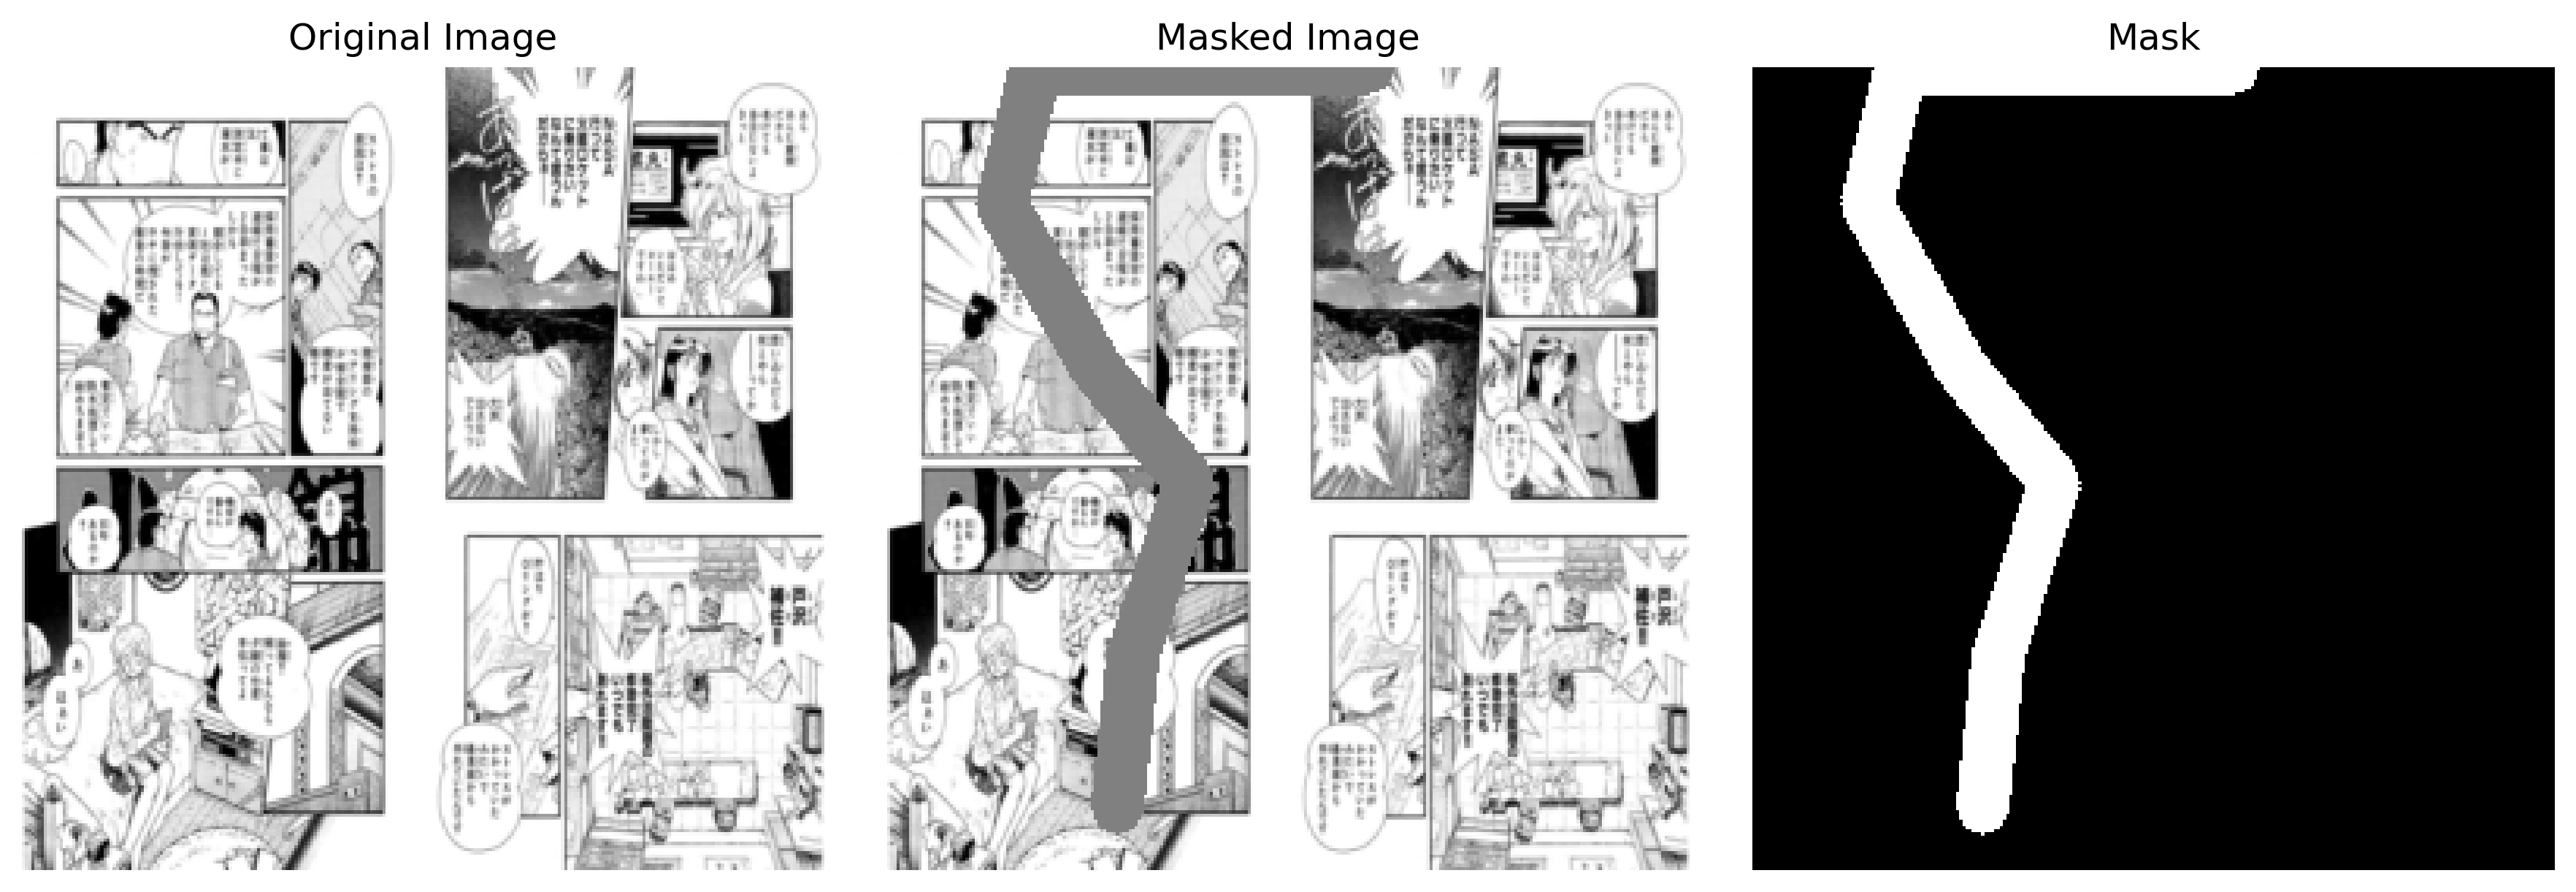

In [25]:
# 👁️ Visualize one sample
def show_sample(sample):
    image = sample['image'].squeeze().numpy()
    masked = sample['masked_image'].squeeze().numpy()
    mask = sample['mask'].squeeze().numpy()

    fig, axs = plt.subplots(1, 3, figsize=(12, 4),dpi=300)
    axs[0].imshow(image, cmap='gray')
    axs[0].set_title("Original Image")
    axs[1].imshow(masked, cmap='gray')
    axs[1].set_title("Masked Image")
    axs[2].imshow(mask, cmap='gray')
    axs[2].set_title("Mask")
    for ax in axs:
        ax.axis('off')
    plt.savefig('sampe.jpg',dpi=300)
    plt.tight_layout()
    plt.show()
    plt.close()

# Show one
sample = train_dataset[10]
show_sample(sample)


In [28]:
# --- GAN Training Loop with Feature Matching and Cyclic Loss Weights ---
best_val_psnr = 0.0
best_epoch = 0
fixed_val_batch = None
scaler_g = torch.amp.GradScaler('cuda')
scaler_d = torch.amp.GradScaler('cuda')

print(f"🚀 Starting final, dynamic GAN training for {CFG.EPOCHS} epochs on {CFG.DEVICE}...")
print(f"   Using a 5-epoch cyclic loss schedule.")

table = ProgressTable(columns=[
    "Epoch", "Step", "G Loss", "D Loss", "Val PSNR", "Val SSIM", "New Best"
])

for epoch in range(1, CFG.EPOCHS + 1):
    model.train()
    discriminator.train()

    # --- Cyclic Loss Weights ---
    epoch_group = (epoch - 1) // 5
    if epoch_group == 0:
        gan_weight, hole_weight, valid_weight, edge_weight, fm_weight = 0.1, 8.0, 1.0, 1.0, 0.0
    elif epoch_group == 1:
        gan_weight, hole_weight, valid_weight, edge_weight, fm_weight = 0.3, 6.0, 0.8, 1.0, 0.1
    elif epoch_group == 2:
        gan_weight, hole_weight, valid_weight, edge_weight, fm_weight = 0.6, 4.5, 0.5, 1.0, 0.2
    elif epoch_group == 3:
        gan_weight, hole_weight, valid_weight, edge_weight, fm_weight = 1.0, 3.5, 0.4, 0.8, 0.3
    else:
        gan_weight, hole_weight, valid_weight, edge_weight, fm_weight = 1.5, 3.0, 0.3, 0.7, 0.5

    if (epoch - 1) % 5 == 0:
        print(f"\n🎯 Epoch {epoch} Loss Weights: GAN={gan_weight}, Hole={hole_weight}, FM={fm_weight}")

    for i, batch in enumerate(train_loader):
        img = batch['image'].to(CFG.DEVICE)
        masked = batch['masked_image'].to(CFG.DEVICE)
        mask = batch['mask'].to(CFG.DEVICE)

        valid = torch.full((img.size(0), 1, 30, 30), 0.9, device=CFG.DEVICE)
        fake = torch.full((img.size(0), 1, 30, 30), 0.1, device=CFG.DEVICE)

        # --- Train Generator ---
        optimizer_G.zero_grad()
        with torch.amp.autocast('cuda'):
            generated_img = model(masked)
            pred_fake_for_G, fake_feats = discriminator(generated_img, return_features=True)
            _, real_feats = discriminator(img.detach(), return_features=True)  # detach to avoid double backward

            loss_GAN = adversarial_loss(pred_fake_for_G, valid)
            loss_hole = l1_loss(generated_img * mask, img * mask)
            loss_valid = l1_loss(generated_img * (1 - mask), img * (1 - mask))
            loss_edge = edge_loss(generated_img, img, mask)

            # Feature Matching Loss
            if fm_weight > 0:
                loss_fm = sum(F.l1_loss(f, r) for f, r in zip(fake_feats, real_feats))
            else:
                loss_fm = torch.tensor(0.0, device=CFG.DEVICE)

            # Total Generator Loss
            loss_G = (
                gan_weight * loss_GAN +
                hole_weight * loss_hole +
                valid_weight * loss_valid +
                edge_weight * loss_edge +
                fm_weight * loss_fm
            )

        scaler_g.scale(loss_G).backward()
        scaler_g.step(optimizer_G)
        scaler_g.update()

        # --- Train Discriminator ---
        optimizer_D.zero_grad()
        with torch.amp.autocast('cuda'):
            pred_real = discriminator(img, return_features=False)
            loss_real = adversarial_loss(pred_real, valid)
            pred_fake_for_D = discriminator(generated_img.detach(), return_features=False)
            loss_fake = adversarial_loss(pred_fake_for_D, fake)
            loss_D = 0.5 * (loss_real + loss_fake)

        scaler_d.scale(loss_D).backward()
        scaler_d.step(optimizer_D)
        scaler_d.update()

        # Table update every 200 steps
        if (i + 1) % 200 == 0:
            table["Epoch"], table["Step"] = f"{epoch}/{CFG.EPOCHS}", f"{i+1}/{len(train_loader)}"
            table["G Loss"], table["D Loss"] = round(loss_G.item(), 4), round(loss_D.item(), 4)

    # --- Validation ---
    model.eval()
    running_psnr, running_ssim = 0.0, 0.0
    with torch.no_grad():
        for batch in val_loader:
            img = batch['image'].to(CFG.DEVICE)
            masked = batch['masked_image'].to(CFG.DEVICE)
            with torch.amp.autocast('cuda'):
                output = model(masked)
            output_0_1 = ((output + 1) / 2).float()
            img_0_1 = ((img + 1) / 2).float()
            running_psnr += psnr(output_0_1, img_0_1, data_range=1.0).item()
            running_ssim += ssim(output_0_1, img_0_1, data_range=1.0).item()

    avg_psnr = running_psnr / len(val_loader)
    avg_ssim = running_ssim / len(val_loader)
    new_best_str = ""
    if avg_psnr > best_val_psnr:
        best_val_psnr, best_epoch = avg_psnr, epoch
        torch.save(model.state_dict(), 'tformer_manga_best_model_256.pth')
        new_best_str = "✅Best Till now"

    # Final row update
    table["Epoch"], table["Step"] = f"{epoch}/{CFG.EPOCHS}", f"{len(train_loader)}/{len(train_loader)}"
    table["G Loss"], table["D Loss"] = round(loss_G.item(), 4), round(loss_D.item(), 4)
    table["Val PSNR"], table["Val SSIM"], table["New Best"] = round(avg_psnr, 2), round(avg_ssim, 4), new_best_str
    table.next_row()

    # Visual inspection output
    if fixed_val_batch is None and CFG.DEVICE.type != 'cpu':
        try:
            fixed_val_batch = next(iter(val_loader))
        except StopIteration:
            fixed_val_batch = {}

    if fixed_val_batch:
        with torch.no_grad():
            img_fixed = fixed_val_batch['image'].to(CFG.DEVICE)
            masked_fixed = fixed_val_batch['masked_image'].to(CFG.DEVICE)
            output_fixed = model(masked_fixed)
            comparison_grid = torch.cat([
                (masked_fixed.cpu() + 1) / 2,
                (output_fixed.cpu() + 1) / 2,
                (img_fixed.cpu() + 1) / 2
            ])
            save_image(comparison_grid, f"epoch_{epoch}_progress_256.png", nrow=len(img_fixed))


🚀 Starting final, dynamic GAN training for 50 epochs on cuda...
   Using a 5-epoch cyclic loss schedule.

🎯 Epoch 1 Loss Weights: GAN=0.1, Hole=8.0, FM=0.0
╭──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────╮
│  Epoch   │   Step   │  G Loss  │  D Loss  │ Val PSNR │ Val SSIM │ New Best │
├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
│   1/50   │ 6788/678…│  0.5808  │  0.2579  │ 22.7300  │  0.8898  │ ✅Best Ti…│
│   2/50   │ 6788/678…│  0.9129  │  0.1690  │ 20.6300  │  0.8433  │          │
│   3/50   │ 6788/678…│  0.8135  │  0.1695  │ 23.9000  │  0.8954  │ ✅Best Ti…│
│   4/50   │ 6788/678…│  0.5460  │  0.1614  │ 23.5200  │  0.9050  │          │
│   5/50   │ 6788/678…│  1.2434  │  0.1283  │ 24.0600  │  0.9033  │ ✅Best Ti…│
🎯 Epoch 6 Loss Weights: GAN=0.3, Hole=6.0, FM=0.1

│   6/50   │ 6788/678…│  0.5928  │  0.1860  │ 24.5900  │  0.9161  │ ✅Best Ti…│
│   7/50   │ 6788/678…│  1.0905  │  0.1678  │ 25.1900  │  0.9203  │ ✅Best Ti…│
│  

In [ ]:
torch.save(model.state_dict(), 'tformer_manga_final_model_256.pth')